In [3]:
import os
os.environ["OMP_NUM_THREADS"] = "1" 

import rasterio
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from rasterio.plot import show

Original image shape: (782, 753)
Data type: float32


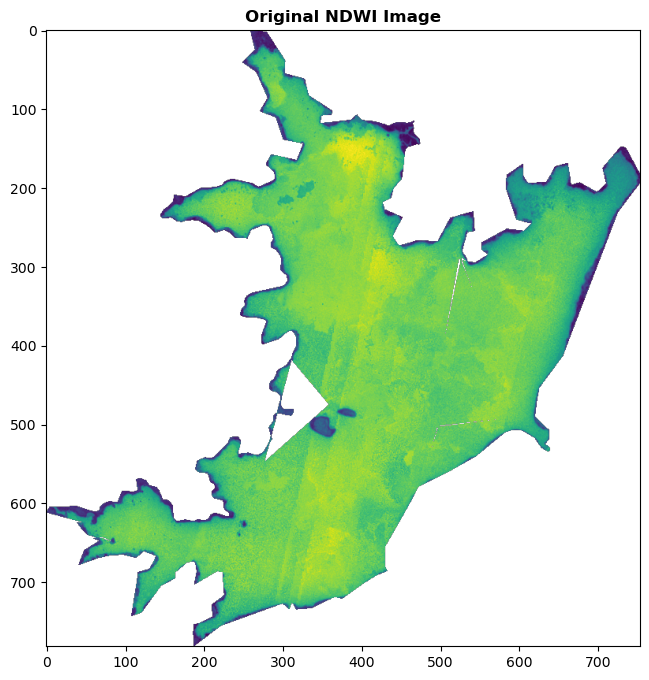

In [ ]:

file_path = 'Weija_NDWI.tif' 
K = 4 

# Load the data and metadata
with rasterio.open(file_path) as src:
    ndwi_array = src.read(1)
    metadata = src.profile 

print(f"Original image shape: {ndwi_array.shape}")
print(f"Data type: {ndwi_array.dtype}")

# Visualize the NDWI array before clustering
plt.figure(figsize=(8, 8))
show(ndwi_array, cmap='viridis', title="Original NDWI Image") 
plt.show()

In [ ]:
# 1. Reshape the 2D array (rows, columns) into a 1D vector (total_pixels, 1_feature)
# The -1 tells numpy to calculate the total number of pixels.
data_vector = ndwi_array.reshape(-1, 1)

# We assume NDWI values near -1.0 or 0.0 are land/background.
# A threshold of -0.2 is often safe to exclude only background.
valid_indices = data_vector > -0.2
filtered_data = data_vector[valid_indices]

print(f"Total valid pixels for clustering: {filtered_data.shape[0]}")


Total valid pixels for clustering: 186000


In [ ]:


# 1. Reshape the 2D array (rows, columns) into a 1D vector (total_pixels, 1_feature)
data_vector = ndwi_array.reshape(-1, 1)

# 2. Filter out NoData values (background pixels outside the lake)
# We assume NDWI values near -1.0 or 0.0 are land/background.
valid_indices = data_vector > -0.2
filtered_data = data_vector[valid_indices] 

# 3. Ensure the filtered data is 2D (N samples, 1 feature)
# The filter operation likely collapsed it to 1D, so we force the 2D shape here.
filtered_data = filtered_data.reshape(-1, 1) 

print(f"Shape ready for K-Means: {filtered_data.shape}")

Shape ready for K-Means: (186000, 1)


In [7]:
# Initialize K-Means model with K=4
# n_init='auto' ensures the algorithm runs multiple times to find the best cluster centers
kmeans = KMeans(n_clusters=K, random_state=42, n_init='auto', max_iter=300)

# Train the model on your filtered NDWI data
kmeans.fit(filtered_data)

# Get the cluster assignment (label) for every pixel used
cluster_labels_filtered = kmeans.labels_

# Get the center value for each cluster (these are the mean NDWI values of the groups)
cluster_centers = kmeans.cluster_centers_

print("--- K-Means Results ---")
print(f"Raw Cluster Centers (Mean NDWI Value for each group):\n{cluster_centers}")


--- K-Means Results ---
Raw Cluster Centers (Mean NDWI Value for each group):
[[ 0.10089631]
 [-0.02430278]
 [ 0.03964964]
 [-0.12429431]]


In [8]:
# ---  MAPPING based on new cluster centers (NDWI > -0.2 Filter) ---
# NOTE: This uses the most accurate cluster centers and interpretation for the report.
category_map = {
    # Index 3 corresponds to the lowest NDWI (-0.1243)
    "Extreme Turbidity/Shallow Edge (-0.124)": 3,       
    
    # Index 1 corresponds to the second lowest NDWI (-0.0243)
    "Highly Turbid Water (-0.024)": 1, 
    
    # Index 2 corresponds to the third lowest NDWI (+0.0396)
    "Moderately Turbid Water (+0.040)": 2, 
    
    # Index 0 corresponds to the highest NDWI (+0.1009)
    "Clearest Water (+0.101)": 0     
}



In [9]:
# --- Configuration based on Sentinel-2 10m resolution ---
pixel_area_sq_m = 10 * 10 # 10m x 10m = 100 square meters per pixel

# 1. Count the number of pixels in each cluster group
cluster_counts = np.bincount(cluster_labels_filtered)
total_valid_pixels = cluster_counts.sum()

print("--- Quantitative Area Analysis (K-Means Output) ---")

# --- MAPPING ---
# NOTE: Indices (0, 1, 2, 3) are mapped to the actual pollution category based on the
# NDWI value they represent.

category_map = {
    # Index 3 corresponds to the lowest NDWI (-0.1243)
    "Extreme Turbidity/Shallow Edge (-0.124)": 3,       
    
    # Index 1 corresponds to the second lowest NDWI (-0.0243)
    "Highly Turbid Water (-0.024)": 1, 
    
    # Index 2 corresponds to the third lowest NDWI (+0.0396)
    "Moderately Turbid Water (+0.040)": 2, 
    
    # Index 0 corresponds to the highest NDWI (+0.1009)
    "Clearest Water (+0.101)": 0   
}

print("| Water Quality Category | Pixels (Count) | Area (km²) | Percentage (%) |")
print("|:-----------------------|:--------------:|:----------:|:--------------:|")

# --- Loop through the interpreted categories and print the results ---
for category, index in category_map.items():
    if index < len(cluster_counts):
        count = cluster_counts[index]
        area_sq_m = count * pixel_area_sq_m
        area_sq_km = area_sq_m / 1_000_000 # Convert m² to km² for readability
        percentage = (count / total_valid_pixels) * 100
        
        print(f"| {category:22} | {count:,} | {area_sq_km:.2f} | {percentage:.1f} |")

--- Quantitative Area Analysis (K-Means Output) ---
| Water Quality Category | Pixels (Count) | Area (km²) | Percentage (%) |
|:-----------------------|:--------------:|:----------:|:--------------:|
| Extreme Turbidity/Shallow Edge (-0.124) | 17,076 | 1.71 | 9.2 |
| Highly Turbid Water (-0.024) | 43,486 | 4.35 | 23.4 |
| Moderately Turbid Water (+0.040) | 75,857 | 7.59 | 40.8 |
| Clearest Water (+0.101) | 49,581 | 4.96 | 26.7 |


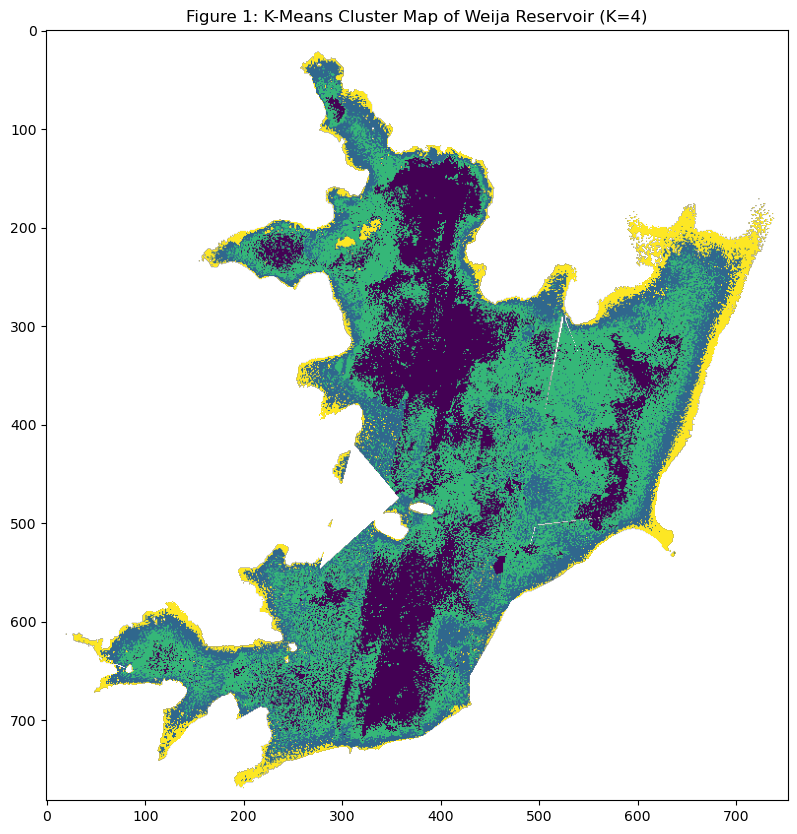

In [10]:
# --- Python Code for Final Map Visualization (Example) ---
# This code generates Figure 1 for the report

import matplotlib.pyplot as plt

# 1. Map the 1D cluster labels back into the 2D grid
# (Assuming ndwi_array and valid_indices are still defined)
cluster_map_array = np.full(ndwi_array.shape, np.nan) 
cluster_map_array[valid_indices.reshape(ndwi_array.shape)] = cluster_labels_filtered

# 2. Plot the map using a color scheme that reflects pollution gradient
plt.figure(figsize=(10, 10))
plt.imshow(cluster_map_array, cmap='viridis') 
plt.title("Figure 1: K-Means Cluster Map of Weija Reservoir (K=4)")


plt.savefig('Weija_Final_Cluster_Map.png', dpi=300) 
plt.show()

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Load and Reshape NDWI array for clustering
# 'ndwi_array' is the flattened spectral data from the Sentinel-2 image
pixels = ndwi_array.reshape(-1, 1)

# 2. Configure and Apply K-Means Clustering 
# k=4 corresponds to: Clearest, Moderate, High, and Extreme Turbidity
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(pixels)

# 3. Reconstruct Cluster Map for Visualization
cluster_map = clusters.reshape(ndwi_array.shape)

# 4. Resulting Statistics
centers = kmeans.cluster_centers_
print("Final Cluster Centers (NDWI):", sorted(centers))


plt.imshow(cluster_map, cmap='viridis')
plt.title('K-Means Automated Turbidity Classification - Weija Reservoir')
plt.colorbar(label='Cluster Index')
plt.show()

ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values